# Toy QPINN on a neutral-atom analog device (QoolQit)

- Inputs $(x,t)$ enter through the **global detuning**; trainable parameters are detuning offsets.
- $u_\theta(x,t)=\langle 0|U_\theta^\dagger(x,t)\,O\,U_\theta(x,t)|0\rangle$ is evaluated with the QoolQit emulator.
- All derivatives (in $x$, $t$ and $\theta$) come from **parameter-shift rules**; there is no autodiff.
- The PDE is manufactured so that its exact solution is itself a quantum model output.

## 1. Model: one global laser driving two atoms

**Physical system.** Two atoms at distance $r=1$, so the Rydberg interaction strength is $J=1/r^6=1$.
Each atom is a qubit: $|0\rangle$ is the ground state, $|1\rangle$ is the Rydberg state, and $n_i=|1\rangle\langle1|_i=\frac{1-Z_i}{2}$.
A single global laser acts on both atoms. We control its Rabi frequency $\Omega(t)$ and detuning $\delta(t)$, with phase $\phi=0$. At any time the Hamiltonian is

$$H(t)=\underbrace{\frac{\Omega(t)}{2}\,(X_1+X_2)}_{\text{laser drive }|0\rangle\leftrightarrow|1\rangle}\;\underbrace{-\;\delta(t)\,(n_1+n_2)}_{\text{detuning (energy of }|1\rangle)}\;+\;\underbrace{J\,n_1n_2}_{\text{interaction, always on}} .$$

**Pulse schedule.** $\Omega(t)$ and $\delta(t)$ are piecewise constant over 5 windows. Every window has duration $T=1$ (`T_MIX`, `T_ENC` in the code):

| window | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|
| $\Omega$ | $\Omega_0$ | $0$ | $\Omega_0$ | $0$ | $\Omega_0$ |
| $\delta$ | $0$ | $x+\theta_1$ | $0$ | $t+\theta_2$ | $0$ |
| Hamiltonian | $H_M$ | $H_E(x+\theta_1)$ | $H_M$ | $H_E(t+\theta_2)$ | $H_M$ |

This gives only two kinds of Hamiltonian:

- **Mixing window** ($\Omega=\Omega_0$, $\delta=0$): $\;H_M=\frac{\Omega_0}{2}(X_1+X_2)+J\,n_1n_2$.
  It contains no input and no trainable parameter. It rotates the atoms between $|0\rangle$ and $|1\rangle$ and entangles them through $J$.
- **Encoding window** ($\Omega=0$, $\delta$ set to a value): $\;H_E(\delta)=-\delta\,(n_1+n_2)+J\,n_1n_2$.
  The inputs and the trainable parameters enter here.

**What is what.**

| symbol | role | where it enters |
|---|---|---|
| $x,\ t$ | **inputs** (PDE coordinates) | detuning of window 2 and window 4 |
| $\theta_1,\ \theta_2$ | **trainable parameters** | offsets added to those two detunings |
| $\Omega_0=1.5,\ T=1,\ J=1$ | fixed | mixing windows and atom positions |
| $O=\frac12(Z_1+Z_2)$ | observable | measured at the end |

Note: the PDE variable $t$ is just an input number written into a detuning. It is **not** the evolution time of the pulse.

**Pauli form.** Substitute $n_i=\frac{1-Z_i}{2}$ and drop terms proportional to the identity, since they only add a global phase:

$$H_M=\frac{\Omega_0}{2}(X_1+X_2)-\frac{J}{4}(Z_1+Z_2)+\frac{J}{4}Z_1Z_2,$$

$$H_E(\delta)=\frac{\delta}{2}(Z_1+Z_2)-\frac{J}{4}(Z_1+Z_2)+\frac{J}{4}Z_1Z_2 .$$

$H_E$ contains only $Z$ operators, so all its terms commute, and

$$e^{-iTH_E(\delta)}=\underbrace{R_Z(\delta T)\otimes R_Z(\delta T)}_{\text{input + parameter}}\;\cdot\;\underbrace{e^{-iT\left[-\frac{J}{4}(Z_1+Z_2)+\frac{J}{4}Z_1Z_2\right]}}_{\text{fixed}},\qquad R_Z(\alpha)=e^{-i\alpha Z/2}.$$

So an encoding window rotates both atoms about the $z$ axis by the angle $x+\theta_1$ (or $t+\theta_2$), and the trainable parameter simply shifts that angle.

**Hypothesis function.** With time running from right to left:

$$U_\theta(x,t)=e^{-iTH_M}\,e^{-iTH_E(t+\theta_2)}\,e^{-iTH_M}\,e^{-iTH_E(x+\theta_1)}\,e^{-iTH_M},\qquad
u_\theta(x,t)=\langle00|\,U_\theta^\dagger\,O\,U_\theta\,|00\rangle .$$

**Why this layout.** Inputs and parameters appear only as rotation angles of the fixed generator $G=\frac12(Z_1+Z_2)$, whose eigenvalues are $\{-1,0,1\}$ and spectral gaps $\{1,2\}$. That is exactly what the parameter-shift rule needs (section 3). The non-commuting $X$ terms live only in $H_M$, which has no parameters.

## 2. Manufactured PDE

$$\partial_t u+\partial_x u=s(x,t),\qquad x\in[-\pi,\pi)\ \text{(periodic)},\ t\in[0,1],\qquad u(x,0)=u_0(x).$$

Pick $\theta^\ast$ and set $s:=(\partial_t+\partial_x)\,u_{\theta^\ast}$ and $u_0:=u_{\theta^\ast}(\cdot,0)$.
Then $u_{\theta^\ast}$ is the exact solution, and it lies in the model class. Periodicity in $x$ is automatic.

Loss (with residual $r=\partial_tu_\theta+\partial_xu_\theta-s$):

$$\mathcal L(\theta)=\frac{1}{|\mathcal C|}\sum_{\mathcal C}r^2+\frac{1}{|\mathcal I|}\sum_{\mathcal I}\big(u_\theta(x,0)-u_0(x)\big)^2 .$$

## 3. Derivatives by (generalized) parameter shift

As a function of one encoding detuning, $f(\delta)=c_0+\sum_k\big[a_k\cos\Delta_k\delta+b_k\sin\Delta_k\delta\big]$ with $\Delta_k\in\{1,\dots,N\}$.
We choose shift rules that are exact on each of these terms:

$$f'(\delta)=\sum_jc_j\big[f(\delta+s_j)-f(\delta-s_j)\big],\qquad f''(\delta)=c'_0f(\delta)+\sum_jc'_j\big[f(\delta+s'_j)+f(\delta-s'_j)\big].$$

Mixed second derivatives use the first-order rule twice. With $\delta_1=x+\theta_1$ and $\delta_2=t+\theta_2$:

$$\partial_xu=\partial_{\delta_1}u,\qquad \partial_tu=\partial_{\delta_2}u,\qquad \frac{\partial r}{\partial\theta_m}=\sum_l\frac{\partial^2u}{\partial\delta_m\partial\delta_l}.$$

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt
from qoolqit import Register, Drive, QuantumProgram, AnalogDevice, ConstantWaveform
from qoolqit.execution import LocalEmulator, EmulationConfig, Occupation

COORDS = [(0.0, 0.0), (1.0, 0.0)]   # 2 atoms at unit distance -> J = 1  (a single atom also works, ~2x faster)
N = len(COORDS)
OMEGA_0 = 1.5                       # Rabi frequency in the mixing windows
T_MIX, T_ENC = 1.0, 1.0             # window durations (total = 3*T_MIX + 2*T_ENC = 5 µs)

register = Register.from_coordinates(COORDS)
device = AnalogDevice()
device.set_energy_unit(1.0)         # 1 energy unit = 1 rad/µs  ->  1 time unit = 1 µs
emulator = LocalEmulator(emulation_config=EmulationConfig(observables=[Occupation(evaluation_times=[1.0])]))

In [5]:
def make_program(deltas):
    # windows in time order: M, E(deltas[0]), M, E(deltas[1]), M
    # M: Omega = OMEGA_0, delta = 0      E: Omega = 0, delta = deltas[l]
    amp = ConstantWaveform(T_MIX, OMEGA_0)
    det = ConstantWaveform(T_MIX, 0.0)
    for d in deltas:
        amp = amp >> ConstantWaveform(T_ENC, 0.0) >> ConstantWaveform(T_MIX, OMEGA_0)
        det = det >> ConstantWaveform(T_ENC, float(d)) >> ConstantWaveform(T_MIX, 0.0)
    return QuantumProgram(register, Drive(amplitude=amp, detuning=det))


def expval(deltas):
    # <O> = (1/N) sum_i <Z_i> = 1 - (2/N) sum_i <n_i>
    program = make_program(deltas)
    program.compile_to(device)
    n = np.array(emulator.run(program).results().occupation[-1])
    return 1.0 - 2.0 * n.mean()


def u(x, t, theta):
    # inputs (x, t) and parameters (theta1, theta2) both go into the encoding detunings
    return expval([x + theta[0], t + theta[1]])

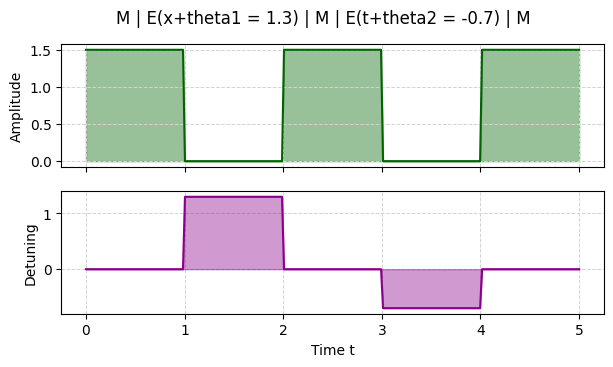

In [6]:
# The pulse schedule for one example point: Omega on top, delta below.
# Horizontal axis = pulse (evolution) time, not the PDE variable t.
x_ex, t_ex, theta_ex = 0.8, 0.3, np.array([0.5, -1.0])
plt.figure(figsize=(7, 3.5))
make_program([x_ex + theta_ex[0], t_ex + theta_ex[1]]).drive.draw()
plt.suptitle(f"M | E(x+theta1 = {x_ex + theta_ex[0]:.1f}) | M | E(t+theta2 = {t_ex + theta_ex[1]:.1f}) | M")
plt.show()

In [7]:
# Shift rules for one encoding window: gaps of G = T_ENC * sum_i Z_i / 2 are k * T_ENC, k = 1..N
gaps = T_ENC * np.arange(1, N + 1)
R = len(gaps)

# 1st order:  f'(d) = sum_j C1_j [f(d + S1_j) - f(d - S1_j)]
S1 = (2 * np.arange(1, R + 1) - 1) * np.pi / (2 * R) / T_ENC
C1 = np.linalg.solve(2 * np.sin(np.outer(gaps, S1)), gaps)

# 2nd order:  f''(d) = C2_0 f(d) + sum_j C2_j [f(d + S2_j) + f(d - S2_j)]
S2 = np.arange(1, R + 1) * np.pi / R / T_ENC
A2 = np.vstack([np.r_[1.0, 2 * np.ones(R)], np.c_[np.ones(R), 2 * np.cos(np.outer(gaps, S2))]])
C2 = np.linalg.solve(A2, np.r_[0.0, -gaps**2])

print("1st order: shifts", S1, "coeffs", C1)
print("2nd order: shifts", S2, "coeffs", C2)

1st order: shifts [0.78539816 2.35619449] coeffs [ 0.85355339 -0.14644661]
2nd order: shifts [1.57079633 3.14159265] coeffs [-1.5   1.   -0.25]


In [8]:
def grad(d):
    # gradient of <O> w.r.t. the encoding detunings
    d = np.asarray(d, float)
    return np.array([sum(c * (expval(d + s * e) - expval(d - s * e)) for c, s in zip(C1, S1))
                     for e in np.eye(len(d))])


def hess(d):
    # Hessian of <O> w.r.t. the encoding detunings
    d = np.asarray(d, float)
    E = np.eye(len(d))
    H = np.zeros((len(d), len(d)))
    f0 = expval(d)
    for l in range(len(d)):
        H[l, l] = C2[0] * f0 + sum(c * (expval(d + s * E[l]) + expval(d - s * E[l])) for c, s in zip(C2[1:], S2))
        for m in range(l + 1, len(d)):
            H[l, m] = H[m, l] = sum(
                ca * cb * (expval(d + sa * E[l] + sb * E[m]) - expval(d + sa * E[l] - sb * E[m])
                           - expval(d - sa * E[l] + sb * E[m]) + expval(d - sa * E[l] - sb * E[m]))
                for ca, sa in zip(C1, S1) for cb, sb in zip(C1, S1))
    return H

In [9]:
theta_star = np.array([-0.5, -0.8])                 # defines the exact solution u* = u_{theta*}

x_col = np.linspace(-np.pi, np.pi, 4, endpoint=False)
colloc = [(x, t) for x in x_col for t in (0.5, 1.0)]  # PDE collocation points
x_ic = np.linspace(-np.pi, np.pi, 4, endpoint=False)  # initial-condition points (t = 0)

src = np.array([grad([x + theta_star[0], t + theta_star[1]]).sum() for x, t in colloc])  # s = u*_x + u*_t
u0 = np.array([u(x, 0.0, theta_star) for x in x_ic])

In [10]:
def loss_and_grad(theta):
    loss, g = 0.0, np.zeros(2)
    for (x, t), s in zip(colloc, src):               # PDE residual
        d = [x + theta[0], t + theta[1]]
        r = grad(d).sum() - s                        # u_x + u_t - s
        dr = hess(d).sum(axis=1)                     # dr/dtheta
        loss += r**2 / len(colloc)
        g += 2 * r * dr / len(colloc)
    for x, y in zip(x_ic, u0):                       # initial condition
        d = [x + theta[0], theta[1]]
        e = expval(d) - y
        loss += e**2 / len(x_ic)
        g += 2 * e * grad(d) / len(x_ic)
    return loss, g


theta = np.zeros(2)
lr = 0.3
history = []
for step in range(15):                               # each step = ~300 emulator runs (a few minutes in total)
    tic = time.time()
    loss, g = loss_and_grad(theta)
    history.append(loss)
    print(f"step {step:2d}  loss {loss:.2e}  theta {np.round(theta, 4)}  ({time.time() - tic:.0f}s)")
    theta = theta - lr * g

print("theta* =", theta_star, "  learned theta =", np.round(theta, 4))

step  0  loss 9.83e-01  theta [0. 0.]  (13s)
step  1  loss 2.18e-01  theta [-0.4315 -0.4017]  (13s)
step  2  loss 1.25e-02  theta [-0.6237 -0.6579]  (13s)
step  3  loss 8.18e-03  theta [-0.5942 -0.6822]  (13s)
step  4  loss 5.25e-03  theta [-0.5784 -0.7094]  (13s)
step  5  loss 3.31e-03  theta [-0.5601 -0.7271]  (14s)
step  6  loss 2.06e-03  theta [-0.5483 -0.7439]  (13s)
step  7  loss 1.26e-03  theta [-0.5372 -0.7558]  (13s)
step  8  loss 7.67e-04  theta [-0.5292 -0.766 ]  (13s)
step  9  loss 4.63e-04  theta [-0.5225 -0.7736]  (13s)
step 10  loss 2.77e-04  theta [-0.5175 -0.7797]  (13s)
step 11  loss 1.65e-04  theta [-0.5134 -0.7843]  (13s)
step 12  loss 9.80e-05  theta [-0.5104 -0.7879]  (13s)
step 13  loss 5.79e-05  theta [-0.508  -0.7907]  (13s)
step 14  loss 3.43e-05  theta [-0.5061 -0.7929]  (13s)
theta* = [-0.5 -0.8]   learned theta = [-0.5047 -0.7946]


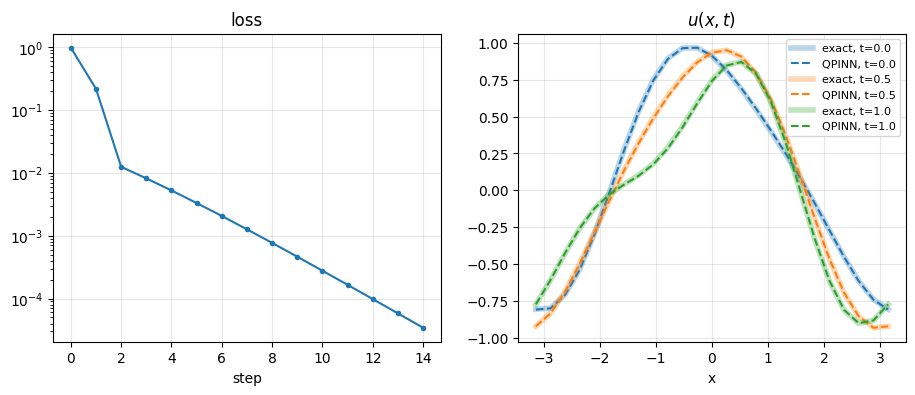

In [11]:
xs = np.linspace(-np.pi, np.pi, 25)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].semilogy(history, ".-")
ax[0].set_xlabel("step"); ax[0].set_title("loss")

for k, t in enumerate([0.0, 0.5, 1.0]):
    ax[1].plot(xs, [u(x, t, theta_star) for x in xs], color=f"C{k}", lw=4, alpha=0.3, label=f"exact, t={t}")
    ax[1].plot(xs, [u(x, t, theta) for x in xs], "--", color=f"C{k}", label=f"QPINN, t={t}")
ax[1].set_xlabel("x"); ax[1].set_title(r"$u(x,t)$"); ax[1].legend(fontsize=8)

for a in ax:
    a.grid(alpha=0.3)
plt.show()